**Train Model**

In [1]:
import os
import dotenv
dotenv.load_dotenv()
import sys
sys.path.append(os.getenv('PROJECT_ROOT'))
from src.dataset import MRIDataset
from src.unet3d_dae import UNet3D
import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader, ConcatDataset
import matplotlib.pyplot as plt

torch.manual_seed(32)

##### 1.0 Data Preparation

In [2]:
# Define data path
t1_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T1')
t2_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T2')

# Define dataset 
t1_dataset = MRIDataset(t1_npz_dir, 1)
t2_dataset = MRIDataset(t2_npz_dir, 2)

t1_dataset.files = t1_dataset.files[:250]
t2_dataset.files = t2_dataset.files[:250]

# Split sizes 
min_size = min(len(t1_dataset), len(t2_dataset))
train_size = int(0.7 * min_size)
val_size = int(0.15 * min_size)

# Create train, val, and test sets separately for T1 and T2
t1_train, t1_val, t1_test = random_split(t1_dataset, [train_size, val_size, len(t1_dataset) - train_size - val_size])
t2_train, t2_val, t2_test = random_split(t2_dataset, [train_size, val_size, len(t2_dataset) - train_size - val_size])

# Merge T1 and T2 to get final datasets
train_dataset = ConcatDataset([t1_train, t2_train])
# val_dataset = ConcatDataset([t1_val, t2_val])
# test_dataset = ConcatDataset([t1_test, t2_test])

# Create DataLoaders
batch_size = 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_t1_loader = DataLoader(t1_val, batch_size=batch_size, shuffle=False)
val_t2_loader = DataLoader(t2_val, batch_size=batch_size, shuffle=False)
test_t1_loader = DataLoader(t1_test, batch_size=batch_size, shuffle=False)
test_t2_loader = DataLoader(t2_test, batch_size=batch_size, shuffle=False)

<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
C:\Users\PC\AppData\Local\Temp\ipykernel_2648\2926283510.py:2: SyntaxWarning: invalid escape sequence '\I'
  t1_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T1')
C:\Users\PC\AppData\Local\Temp\ipykernel_2648\2926283510.py:3: SyntaxWarning: invalid escape sequence '\I'
  t2_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T2')


##### 2.0 Setting Up Hyperparameters

In [3]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and move it to the selected device
model = UNet3D().to(device)

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Define number of epochs
n_epochs = 30

##### 3.0 Model Training

In [4]:
# Training loop
training_losses = []
validation_t1_losses = []
validation_t2_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for ground_truth, noisy_image, _, modality in train_loader:
        ground_truth, noisy_image, modality = ground_truth.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)

        optimizer.zero_grad()
        output = model(noisy_image, modality)
        loss = nn.MSELoss()(output, ground_truth)
        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()

    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')
    avg_train_loss = epoch_loss / len(train_loader)
    training_losses.append(avg_train_loss)
    
    # Run Validation
    model.eval()  # Set model to evaluation mode
    val_t1_loss = 0.0
    val_t2_loss = 0.0

    with torch.no_grad():
        for ground_truth, noisy_image, _, modality in val_t1_loader:
            ground_truth, noisy_image, modality = ground_truth.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = nn.MSELoss()(output, ground_truth)
            val_t1_loss += loss.item()
        for ground_truth, noisy_image, _, modality in val_t2_loader:
            ground_truth, noisy_image, modality = ground_truth.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = nn.MSELoss()(output, ground_truth)
            val_t2_loss += loss.item()

    avg_val_t1_loss = val_t1_loss / len(val_t1_loader)
    validation_t1_losses.append(avg_val_t1_loss)
    avg_val_t2_loss = val_t2_loss / len(val_t2_loader)
    validation_t2_losses.append(avg_val_t2_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}] - Train Loss: {avg_train_loss:.6f} - T1 Val Loss: {avg_val_t1_loss:.6f} - T2 Val Loss: {avg_val_t2_loss:.6f}")

Epoch [1/30] - Train Loss: 0.003823 - T1 Val Loss: 0.001244 - T2 Val Loss: 0.001548
Epoch [2/30] - Train Loss: 0.001184 - T1 Val Loss: 0.001010 - T2 Val Loss: 0.001022
Epoch [3/30] - Train Loss: 0.001004 - T1 Val Loss: 0.000986 - T2 Val Loss: 0.000925
Epoch [4/30] - Train Loss: 0.000889 - T1 Val Loss: 0.000881 - T2 Val Loss: 0.000880
Epoch [5/30] - Train Loss: 0.000869 - T1 Val Loss: 0.001107 - T2 Val Loss: 0.000831
Epoch [6/30] - Train Loss: 0.000812 - T1 Val Loss: 0.000989 - T2 Val Loss: 0.000842
Epoch [7/30] - Train Loss: 0.000819 - T1 Val Loss: 0.000799 - T2 Val Loss: 0.000733
Epoch [8/30] - Train Loss: 0.000781 - T1 Val Loss: 0.000837 - T2 Val Loss: 0.000709
Epoch [9/30] - Train Loss: 0.000733 - T1 Val Loss: 0.000792 - T2 Val Loss: 0.000699
Epoch [10/30] - Train Loss: 0.000719 - T1 Val Loss: 0.000892 - T2 Val Loss: 0.000622


KeyboardInterrupt: 

In [ ]:
# Save model 
torch.save(model.state_dict(), "full_model_weights.pth") 

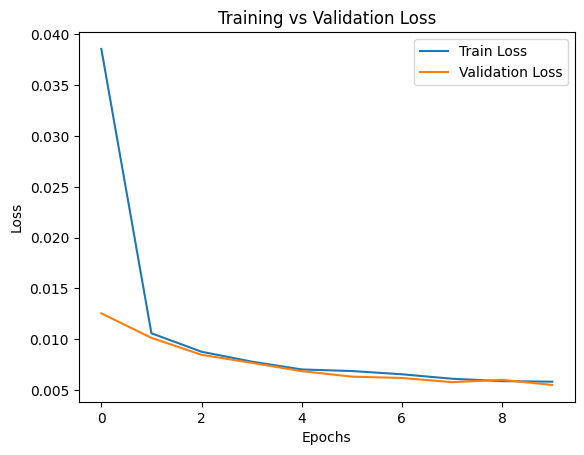

In [ ]:
# Visualise training and validation losses
plt.plot(training_losses, label="Train Loss")
plt.plot(validation_t1_losses, label="Validation Loss (T1)")
plt.plot(validation_t2_losses, label="Validation Loss (T2)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

##### 4.0 Model Testing

In [ ]:
# Ensure model is in evaluation mode
model.eval()

# Initialize loss tracking
test_t1_losses = []
test_loss_t1_total = 0.0

test_t2_losses = []
test_loss_t2_total = 0.0

# Loop through testing dataset
for ground_truth, noisy_image, _, modality in test_t1_loader:
    ground_truth, noisy_image, modality = ground_truth.to(device), noisy_image.to(device), modality.to(device)
    
    with torch.no_grad():
        output = model(noisy_image, modality)
        loss = nn.MSELoss()(output, ground_truth)
    
    test_t1_losses.append(loss.item())
    test_loss_t1_total += loss.item()

for ground_truth, noisy_image, _, modality in test_t2_loader:
    ground_truth, noisy_image, modality = ground_truth.to(device), noisy_image.to(device), modality.to(device)
    
    with torch.no_grad():
        output = model(noisy_image, modality)
        loss = nn.MSELoss()(output, ground_truth)
    
    test_t2_losses.append(loss.item())
    test_loss_t2_total += loss.item()

# Compute average validation loss
avg_val_t1_loss = test_loss_t1_total / len(test_t1_loader)
avg_val_t2_loss = test_loss_t2_total / len(test_t2_loader)
print(f"T1 Test Loss: {avg_val_t1_loss:.6f} - T2 Test Loss: {avg_val_t2_loss:.6f}")

Test Loss: 0.005444


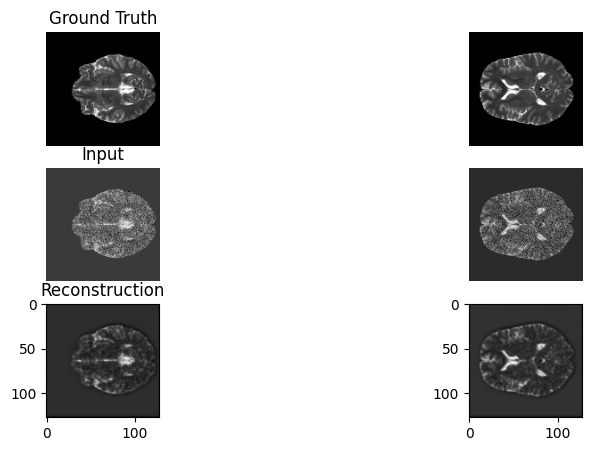

In [ ]:
# Visualization of reconstructions (first batch only)
num_samples = noisy_image.shape[0]  
inputs_np = noisy_image.cpu().numpy()
recon_np = output.cpu().numpy()
original_np = ground_truth.cpu().numpy()

fig, axes = plt.subplots(3, num_samples, figsize=(10, 5))

for i in range(num_samples):
    ori_slice = original_np[i, 0, :, :, original_np.shape[-1] // 2]  # Middle slice along depth
    mid_slice = inputs_np[i, 0, :, :, inputs_np.shape[-1] // 2]  # Middle slice along depth
    recon_slice = recon_np[i, 0, :, :, recon_np.shape[-1] // 2]  # Middle slice along depth

    axes[0, i].imshow(ori_slice, cmap="gray")  # Ground truth
    axes[1, i].imshow(mid_slice, cmap="gray")  # Input
    axes[2, i].imshow(recon_slice, cmap="gray")  # Reconstruction
    axes[0, i].axis("off")
    axes[1, i].axis("off")

axes[0, 0].set_title("Ground Truth")
axes[1, 0].set_title("Input")
axes[2, 0].set_title("Reconstruction")

plt.show()